<a href="https://colab.research.google.com/github/karimullakhan9189/customer-churn-prediction-ml/blob/main/Costumer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

In [ ]:
np.random.seed(42)

n = 1000

data = pd.DataFrame({
    'Age': np.random.randint(18, 60, n),
    'Balance': np.random.randint(1000, 100000, n),
    'Salary': np.random.randint(20000, 150000, n),
    'Tenure': np.random.randint(1, 10, n),
    'NumProducts': np.random.randint(1, 4, n),
    'IsActive': np.random.randint(0, 2, n)
})

# Create churn logic
data['Churn'] = ((data['Balance'] > 50000) & (data['IsActive'] == 0)).astype(int)

print(data.head())

   Age  Balance  Salary  Tenure  NumProducts  IsActive  Churn
0   56    15382  146365       9            2         0      0
1   46    85291   75409       6            3         1      0
2   32     4756   48625       1            3         1      0
3   25    21609  101040       1            2         1      0
4   38    17478   44089       6            1         1      0


In [ ]:
X = data.drop('Churn', axis=1)
y = data['Churn']

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
lr = LogisticRegression()
rf = RandomForestClassifier()

In [ ]:
lr_cv = cross_val_score(lr, X_scaled, y, cv=5)
rf_cv = cross_val_score(rf, X_scaled, y, cv=5)

print("Logistic Regression CV Accuracy:", lr_cv.mean())
print("Random Forest CV Accuracy:", rf_cv.mean())

Logistic Regression CV Accuracy: 0.992
Random Forest CV Accuracy: 0.9970000000000001


In [ ]:
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

y_prob_lr = lr.predict_proba(X_test)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [ ]:
def evaluate(y_test, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

In [ ]:
lr_results = evaluate(y_test, y_pred_lr, y_prob_lr)
rf_results = evaluate(y_test, y_pred_rf, y_prob_rf)

results = pd.DataFrame([lr_results, rf_results],
                       index=["Logistic Regression", "Random Forest"])

print(results)

                     Accuracy  Precision    Recall  F1 Score   ROC-AUC
Logistic Regression     0.995        1.0  0.982759  0.991304  0.999879
Random Forest           1.000        1.0  1.000000  1.000000  1.000000


In [ ]:
print("Logistic Regression Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Random Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Logistic Regression Confusion Matrix:
 [[142   0]
 [  1  57]]
Random Forest Confusion Matrix:
 [[142   0]
 [  0  58]]


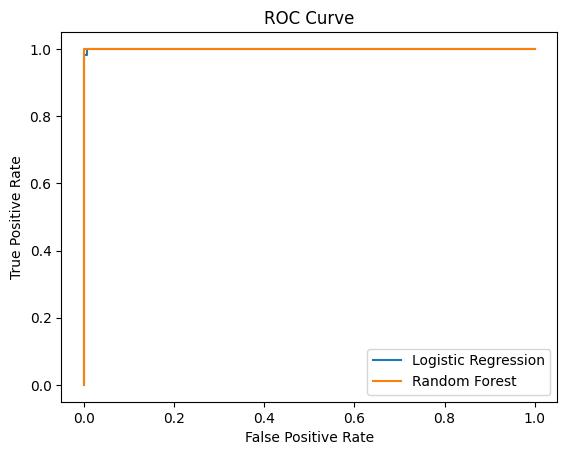

In [ ]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure()
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True)
}

In [ ]:
results = []

for name, model in models.items():

    # Cross-validation
    cv_score = cross_val_score(model, X_scaled, y, cv=5).mean()

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results.append([name, cv_score, acc, prec, rec, f1, roc])

# Create DataFrame
results_df = pd.DataFrame(results, columns=[
    "Model", "CV Accuracy", "Test Accuracy",
    "Precision", "Recall", "F1 Score", "ROC-AUC"
])

print(results_df)

                 Model  CV Accuracy  Test Accuracy  Precision    Recall  \
0  Logistic Regression        0.992          0.995   1.000000  0.982759   
1        Random Forest        0.998          1.000   1.000000  1.000000   
2        Decision Tree        1.000          1.000   1.000000  1.000000   
3                  KNN        0.963          0.950   0.961538  0.862069   
4                  SVM        0.979          0.980   1.000000  0.931034   

   F1 Score   ROC-AUC  
0  0.991304  0.999879  
1  1.000000  1.000000  
2  1.000000  1.000000  
3  0.909091  0.976506  
4  0.964286  0.997875  


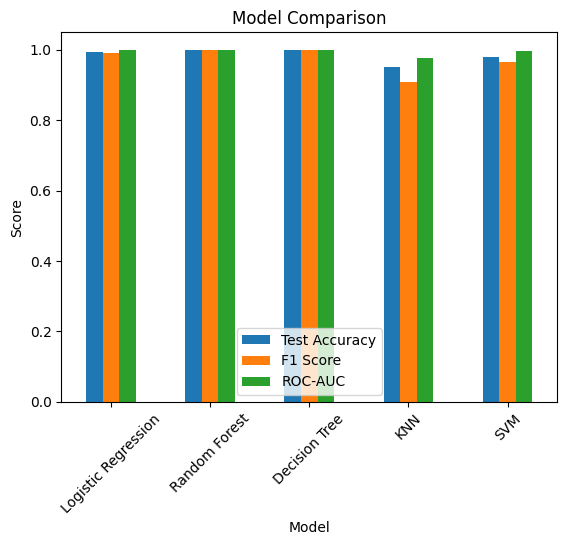

In [ ]:
results_df.set_index("Model")[["Test Accuracy", "F1 Score", "ROC-AUC"]].plot(kind='bar')

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

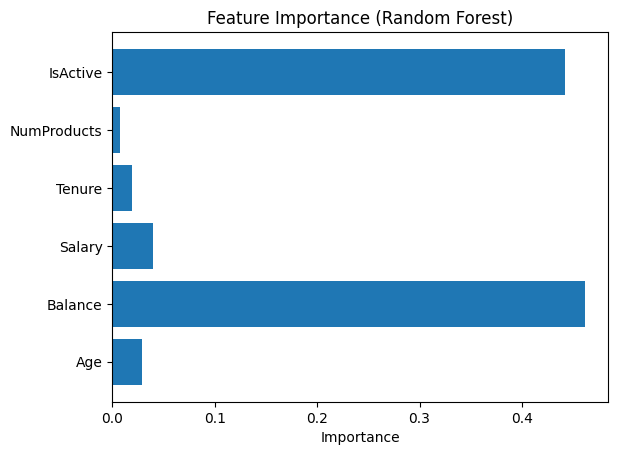

In [ ]:
importances = rf.feature_importances_

feature_names = X.columns

plt.figure()
plt.barh(feature_names, importances)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()